### Experiment 8: Outlier Sensitivity
## Research Question

How sensitive is Linear Regression to extreme observations, and how does
handling outliers in the training data affect its generalization
performance?

## Hypothesis

Extreme observations in the training data are expected to have a
disproportionate influence on Linear Regression because the squared-error
objective penalizes large residuals strongly.

Removing or reducing the influence of extreme observations is expected
to improve generalization if these observations are highly influential.
However, excessive removal of observations may discard useful
information and reduce predictive performance.



## Experimental Principle

The validation set will remain completely unchanged throughout the
experiment.

Outlier handling will be applied only to the training data. The same
features, preprocessing, train-validation split, model type, and
evaluation metrics will be used for all experiments.

Only the treatment of extreme observations in the training data will be
varied.

In [2]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_27044\4013469833.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
X = df.drop(columns=["median_house_value"])
y =df['median_house_value']

In [5]:
from sklearn.model_selection import train_test_split

#Split the raw data inot train test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=12)

In [9]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

X_train_subset = X_train[features]
X_val_subset = X_val[features]

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [12]:
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train_subset)
X_val_imputed = imputer.transform(X_val_subset)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

### Identify Target Outliers

In [6]:
import numpy as np
import pandas as pd

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 119300.0
Q3: 263800.0
IQR: 144500.0
Lower bound: -97450.0
Upper bound: 480550.0


### Count the Outliers

In [7]:
outlier_mask = (
    (y_train < lower_bound) |
    (y_train > upper_bound)
)

print("Number of training observations:", len(y_train))
print("Number of target outliers:", outlier_mask.sum())

print(
    "Percentage of target outliers:",
    outlier_mask.mean() * 100
)

Number of training observations: 16512
Number of target outliers: 849
Percentage of target outliers: 5.1417151162790695


### Create the Outlier-Removed Dataset

In [14]:
X_train_no_outliers = X_train_scaled[
    ~outlier_mask
]

y_train_no_outliers = y_train[
    ~outlier_mask
]

### Train the model:

In [15]:
model_no_outliers = LinearRegression()

model_no_outliers.fit(
    X_train_no_outliers,
    y_train_no_outliers
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-79368.04,-83202.89, 11721.68,...,-37497.13, 29350.51, 71601.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.995e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[248.23,173.48,120.25,..., 35.61, 26.19, 17.99]"


### Prediction

In [16]:
y_train_pred_no_outliers = (
    model_no_outliers.predict(
        X_train_no_outliers
    )
)

y_val_pred_no_outliers = (
    model_no_outliers.predict(
        X_val_scaled
    )
)

### Winsorization
Instead of deleting observations, we'll cap extreme target values


In [17]:
y_train_winsorized = y_train.clip(
    lower=lower_bound,
    upper=upper_bound
)

In [ ]:
#train the model
model_winsorized = LinearRegression()

model_winsorized.fit(
    X_train_scaled,
    y_train_winsorized
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-86327.52,-91721.33, 13611.34,...,-47600.71, 33995.16, 71904.89]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.052e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[253.95,177.45,132.82,..., 36.59, 27.78, 18.31]"


In [19]:
#prediction
y_train_pred_winsorized = (
    model_winsorized.predict(
        X_train_scaled
    )
)

y_val_pred_winsorized = (
    model_winsorized.predict(
        X_val_scaled
    )
)

### Baseline

For comparison, train normal model:

In [20]:
model_baseline = LinearRegression()

model_baseline.fit(
    X_train_scaled,
    y_train
)

y_train_pred_baseline = (
    model_baseline.predict(
        X_train_scaled
    )
)

y_val_pred_baseline = (
    model_baseline.predict(
        X_val_scaled
    )
)

### Comparison Table

In [21]:
results = []

models_predictions = {
    "Baseline": (
        y_train,
        y_train_pred_baseline,
        y_val_pred_baseline
    ),
    
    "Outliers Removed": (
        y_train_no_outliers,
        y_train_pred_no_outliers,
        y_val_pred_no_outliers
    ),
    
    "Winsorized": (
        y_train_winsorized,
        y_train_pred_winsorized,
        y_val_pred_winsorized
    )
}

In [22]:
for name, (
    y_train_actual,
    y_train_pred,
    y_val_pred
) in models_predictions.items():

    results.append({
        "Method": name,

        "Train_RMSE": np.sqrt(
            mean_squared_error(
                y_train_actual,
                y_train_pred
            )
        ),

        "Validation_RMSE": np.sqrt(
            mean_squared_error(
                y_val,
                y_val_pred
            )
        ),

        "Train_MAE": mean_absolute_error(
            y_train_actual,
            y_train_pred
        ),

        "Validation_MAE": mean_absolute_error(
            y_val,
            y_val_pred
        ),

        "Train_R2": r2_score(
            y_train_actual,
            y_train_pred
        ),

        "Validation_R2": r2_score(
            y_val,
            y_val_pred
        )
    })

results_8 = pd.DataFrame(results)

results_8

,Method,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2
0,Baseline,69389.154322,70858.656956,50773.476720,51298.989683,0.635618,0.633822
1,Outliers Removed,60101.091476,71205.613010,44911.186046,50685.358553,0.599762,0.630227
2,Winsorized,67980.762003,70894.240081,50079.004780,51261.394779,0.635293,0.633454


### Visualize the Results

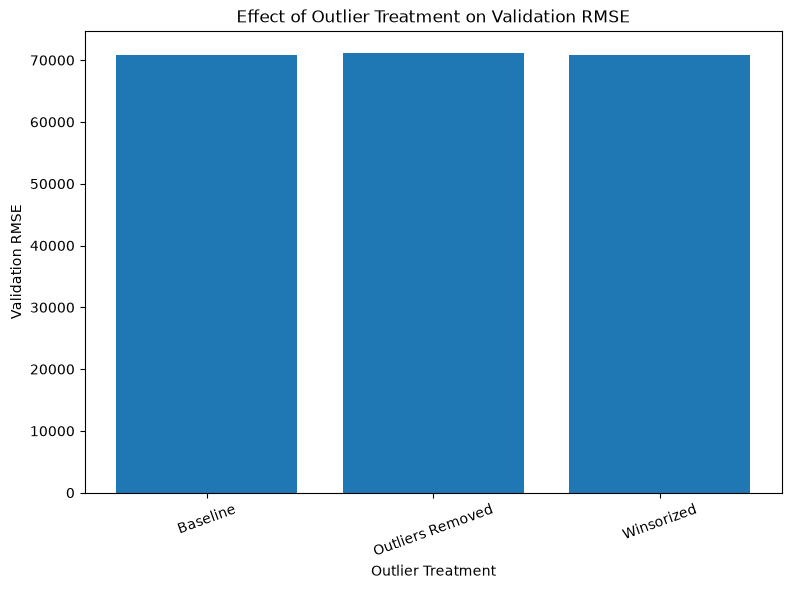

In [23]:
plt.figure(figsize=(9, 6))

plt.bar(
    results_8["Method"],
    results_8["Validation_RMSE"]
)

plt.xlabel("Outlier Treatment")
plt.ylabel("Validation RMSE")
plt.title("Effect of Outlier Treatment on Validation RMSE")
plt.xticks(rotation=20)

plt.show()

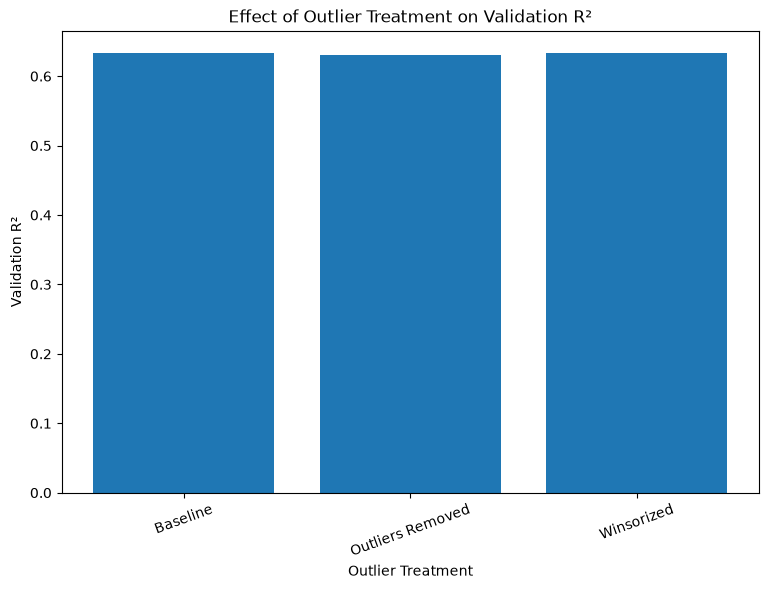

In [24]:
plt.figure(figsize=(9, 6))

plt.bar(
    results_8["Method"],
    results_8["Validation_R2"]
)

plt.xlabel("Outlier Treatment")
plt.ylabel("Validation R²")
plt.title("Effect of Outlier Treatment on Validation R²")
plt.xticks(rotation=20)

plt.show()

## Conclusion

Outlier treatment did not improve the generalization performance of Linear Regression. 
The baseline model achieved a validation RMSE of approximately 70,859 and R² of 0.634. 
Removing outliers increased validation RMSE to approximately 71,206 and reduced R² to 
0.630, while winsorization produced results nearly identical to the baseline 
(RMSE ≈ 70,894, R² ≈ 0.633).

Interestingly, removing outliers substantially reduced training RMSE from approximately 
69,389 to 60,101 without improving validation performance. This indicates that better 
training fit did not translate into better generalization.

Therefore, the results provide partial support for the hypothesis that extreme 
observations can influence Linear Regression, but they do not support the expectation 
that removing or reducing their influence improves predictive performance. In the 
California Housing dataset, statistically extreme observations may contain useful 
information rather than representing erroneous data.

## Hypothesis Result

**Hypothesis: Partially Supported**

The results show that outlier treatment affected training performance, but did not improve
generalization. Removing outliers reduced training RMSE from approximately **69,389 to
60,101**, but validation RMSE increased from **70,859 to 71,206** and validation R²
decreased from **0.634 to 0.630**.

Winsorization produced results nearly identical to the baseline, with validation RMSE of
approximately **70,894** and R² of **0.633**.

Therefore, the results partially support the hypothesis that extreme observations can
influence Linear Regression, but do not support the expectation that removing or reducing
their influence improves predictive performance.